# 04 - Community Detection v2

In [ ]:
# ── Repository root ───────────────────────────────────────────────────────────
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'legacy') else Path.cwd()
assert (ROOT / 'data').is_dir(), f'Repository root not found from {Path.cwd()}'

## 0 — Parametri

In [ ]:
BACKBONE_PATH   = ROOT / 'data' / 'networks' / 'annual_backbone.graphml.gz'
SPECIES_PATH    = ROOT / 'data' / 'raw' / 'species.csv.gz'
NETWORKS_DIR    = ROOT / 'data' / 'networks'
FIGURES_DIR     = ROOT / 'figures'
OUT_ANNUAL      = NETWORKS_DIR / 'community_assignments_annual_v2.csv.gz'
OUT_SEASONAL    = NETWORKS_DIR / 'community_assignments_seasonal_v2.csv.gz'
OUT_JSON        = ROOT / 'data' / 'analysis' / 'community_results_v2.json'

WEIGHT_ATTR     = 'jaccard'   # peso usato da Louvain, Leiden, CNM, Infomap
RANDOM_SEED     = 42

N_RUNS          = 50          # run per gli algoritmi stocastici
N_RUNS_LEIDEN   = 10          
N_RUNS_SWEEP    = 10          # run per ogni gamma del sweep
GAMMAS          = [0.75, 0.875, 1.0, 1.125, 1.25, 1.5, 2.0]
INFOMAP_TRIALS  = 10          # num_trials interni di Infomap

MIN_COMMUNITY_SIZE    = 10    # soglia per il calcolo della purity
PURITY_THRESHOLD      = 0.70
PURITY_NORM_THRESHOLD = 0.30

N_NULL          = 10          # realizzazioni ER/BA

SEASONS      = ['winter_0', 'spring', 'summer', 'autumn', 'winter_1']
SEASON_NAMES = {'winter_0': 'Winter_0', 'spring': 'Spring', 'summer': 'Summer',
                'autumn': 'Autumn', 'winter_1': 'Winter_1'}
GAMMAS_SEASONAL = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
MIN_SIZE_FILTER = 5

ICONIC_PAL = {
    'Insecta': '#4C9B7A', 'Aves': '#5B8EB8', 'Reptilia': '#C7A540',
    'Amphibia': '#7B61A8', 'Mammalia': '#C7563C', 'Arachnida': '#8B4513',
    'Actinopterygii': '#20B2AA', 'Mollusca': '#FF8C69', 'Other': '#AAAAAA',
}
INFORMATIVE_TAXA = set(ICONIC_PAL.keys()) - {'Other'}

ALGO_PAL = {
    'Louvain': '#2C5F8A', 'Leiden': '#4C9B7A', 'Greedy Mod.': '#C7A540',
    'Infomap': '#C7563C', 'Label Prop.': '#7B61A8',
}

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(ROOT / 'data' / 'analysis', exist_ok=True)
print('Parameters set.')

Parameters set.


## 1 - Imports

In [2]:
import json, time, warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from cdlib import algorithms
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from infomap import Infomap

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='ticks', context='paper', font_scale=1.1, rc={
    'font.family': 'serif', 'axes.linewidth': 0.7,
    'grid.linewidth': 0.4, 'grid.alpha': 0.3,
})

def savefig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{FIGURES_DIR}/{name}.{ext}', dpi=300,
                    bbox_inches='tight', pad_inches=0.05)
    print(f'  saved {FIGURES_DIR}/{name}.png + .pdf')

print('Imports OK.')

Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer'}
Imports OK.


In [3]:
t0 = time.time()
B = nx.read_graphml(BACKBONE_PATH)
try:
    B = nx.relabel_nodes(B, {n: int(n) for n in B.nodes()})
except ValueError:
    pass

gcc_nodes = max(nx.connected_components(B), key=len)
G = B.subgraph(gcc_nodes).copy()

print(f'Backbone : {B.number_of_nodes():,} nodi | {B.number_of_edges():,} archi')
print(f'GCC      : {G.number_of_nodes():,} nodi | {G.number_of_edges():,} archi '
      f'({100*G.number_of_nodes()/B.number_of_nodes():.1f}%)')
print(f'Caricato in {time.time()-t0:.1f}s')

Backbone : 3,023 nodi | 134,305 archi
GCC      : 3,009 nodi | 134,298 archi (99.5%)
Caricato in 6.6s


In [4]:
# Mappa taxon_id -> iconic_taxon, con fallback su species.csv
iconic_map = {}
for n, d in G.nodes(data=True):
    val = d.get('iconic_taxon', None)
    if val and val not in ('None', '', 'nan'):
        iconic_map[n] = val

missing = [n for n in G.nodes() if n not in iconic_map]
if missing and os.path.exists(SPECIES_PATH):
    sp = pd.read_csv(SPECIES_PATH)
    sp_map = sp.set_index('taxon_id')['iconic_taxon'].to_dict()
    for n in missing:
        if n in sp_map:
            iconic_map[n] = sp_map[n]

# I taxa non informativi ('Animalia' e simili) confluiscono in 'Other'
iconic_map = {n: (v if v in INFORMATIVE_TAXA else 'Other')
              for n, v in iconic_map.items()}

taxon_counts  = Counter(iconic_map.values())
n_total       = sum(taxon_counts.values())
BASELINE_FREQ = {t: c / n_total for t, c in taxon_counts.items()}

print(f'Copertura iconic_taxon: {len(iconic_map):,}/{G.number_of_nodes():,} '
      f'({100*len(iconic_map)/G.number_of_nodes():.1f}%)')
print()
print(f'{"Taxon":<20}{"Count":>8}{"%":>9}')
print('-' * 37)
for t, c in taxon_counts.most_common():
    print(f'  {t:<18}{c:>8d}{100*c/n_total:>8.1f}%')

Copertura iconic_taxon: 3,009/3,009 (100.0%)

Taxon                  Count        %
-------------------------------------
  Insecta               1981    65.8%
  Aves                   316    10.5%
  Other                  156     5.2%
  Mollusca               154     5.1%
  Arachnida              125     4.2%
  Actinopterygii         113     3.8%
  Mammalia                63     2.1%
  Reptilia                60     2.0%
  Amphibia                41     1.4%


## 3 - Functions

In [5]:
def weighted_q(G, partition, weight=WEIGHT_ATTR):
    """Modularita' pesata (Jaccard): quella ottimizzata da Louvain/Leiden/CNM."""
    try:
        return nx.community.modularity(G, [set(c) for c in partition], weight=weight)
    except Exception:
        return np.nan


def unweighted_q(G, partition):
    """Modularita' non pesata (Newman-Girvan), per confronto con la letteratura."""
    try:
        return nx.community.modularity(G, [set(c) for c in partition], weight=None)
    except Exception:
        return np.nan


def partition_to_labels(partition, nodes):
    """Converte una lista di insiemi in un vettore di etichette allineato a `nodes`."""
    lab = {}
    for i, com in enumerate(partition):
        for n in com:
            lab[n] = i
    return np.array([lab.get(n, -1) for n in nodes])


def partition_stats(G, partition, label, extra=None):
    """Riga di riepilogo per una partizione."""
    sizes = sorted((len(c) for c in partition), reverse=True)
    row = {
        'Algorithm':      label,
        '#Com.':          len(sizes),
        'Q_w':            round(weighted_q(G, partition), 4),
        'Q_uw':           round(unweighted_q(G, partition), 4),
        'Largest (%)':    round(100 * sizes[0] / G.number_of_nodes(), 1),
        'Median size':    int(np.median(sizes)),
        'Com. >= 5':      sum(1 for s in sizes if s >= 5),
    }
    if extra:
        row.update(extra)
    return row


print('Funzioni definite.')

Funzioni definite.


## 4 - Infomap

In [ ]:
def run_infomap(G, weight=WEIGHT_ATTR, trials=INFOMAP_TRIALS, seed=RANDOM_SEED,
                two_level=True):
    """Esegue Infomap su un grafo networkx e restituisce (partizione, codelength).

    partizione = lista di insiemi di nodi (stesso formato degli altri algoritmi).
    """
    nodes = list(G.nodes())
    idx   = {n: i for i, n in enumerate(nodes)}

    args = '--two-level' if two_level else ''
    im = Infomap(args, silent=True, num_trials=trials, seed=seed)

    for u, v, d in G.edges(data=True):
        w = float(d.get(weight, 1.0)) if weight else 1.0
        im.add_link(idx[u], idx[v], max(w, 1e-9))

    im.run()

    comm = defaultdict(set)
    for node in im.nodes:
        comm[node.module_id].add(nodes[node.node_id])

    return list(comm.values()), im.codelength


t0 = time.time()
_test_part, _test_cl = run_infomap(G)
print(f'Infomap OK: {len(_test_part)} moduli, codelength = {_test_cl:.4f} bit '
      f'({time.time()-t0:.1f}s)')

Infomap OK: 15 moduli, codelength = 9.5362 bit (2.1s)


## 5 - Resolution sweep di Louvain

In [7]:
sweep_rows = []
print(f'{"gamma":>7}{"k":>6}{"Q_w":>10}{"Q_uw":>10}{"largest%":>11}')
print('-' * 44)

for gamma in GAMMAS:
    best, best_q = None, -np.inf
    for _ in range(N_RUNS_SWEEP):
        coms = algorithms.louvain(G, weight=WEIGHT_ATTR, resolution=gamma, randomize=True)
        q = weighted_q(G, coms.communities)
        if q > best_q:
            best_q, best = q, coms.communities
    sizes = sorted((len(c) for c in best), reverse=True)
    q_uw  = unweighted_q(G, best)
    largest = 100 * sizes[0] / G.number_of_nodes()
    print(f'{gamma:>7.3f}{len(sizes):>6d}{best_q:>10.4f}{q_uw:>10.4f}{largest:>10.1f}%')
    sweep_rows.append({'gamma': gamma, 'k': len(sizes), 'Q_w': best_q,
                       'Q_uw': q_uw, 'largest_pct': largest})

GAMMA_OPT = max(sweep_rows, key=lambda r: r['Q_w'])['gamma']
print()
print(f'gamma* = {GAMMA_OPT}')

  gamma     k       Q_w      Q_uw   largest%
--------------------------------------------
  0.750    11    0.2607    0.1939      38.5%
  0.875     7    0.2665    0.2040      35.0%
  1.000     7    0.2679    0.2089      33.0%
  1.125     9    0.2670    0.2099      25.0%
  1.250    19    0.2621    0.2071      22.6%
  1.500    36    0.2358    0.1827      17.7%
  2.000    73    0.2053    0.1505      15.7%

gamma* = 1.0


## 6 - algo runs

In [ ]:
partitions = {}     
extras     = {}     

# ── 1. Louvain ───────────────────────────────────────────────────────────────
t0 = time.time()
best, best_q = None, -np.inf
for _ in range(N_RUNS):
    coms = algorithms.louvain(G, weight=WEIGHT_ATTR, resolution=GAMMA_OPT, randomize=True)
    q = weighted_q(G, coms.communities)
    if q > best_q:
        best_q, best = q, coms.communities
partitions['Louvain'] = best
print(f'Louvain      k={len(best):>4d}  Q_w={best_q:.4f}  ({time.time()-t0:.1f}s)')

# ── 2. Leiden ────────────────────────────────────────────────────────────────
t0 = time.time()
best, best_q = None, -np.inf
for _ in range(N_RUNS_LEIDEN):
    coms = algorithms.leiden(G, weights=WEIGHT_ATTR)
    q = weighted_q(G, coms.communities)
    if q > best_q:
        best_q, best = q, coms.communities
partitions['Leiden'] = best
print(f'Leiden       k={len(best):>4d}  Q_w={best_q:.4f}  ({time.time()-t0:.1f}s)')

# ── 3. Greedy Modularity (CNM) — deterministico ──────────────────────────────
t0 = time.time()
gm = list(nx.community.greedy_modularity_communities(G, weight=WEIGHT_ATTR))
partitions['Greedy Mod.'] = [set(c) for c in gm]
print(f'Greedy Mod.  k={len(gm):>4d}  Q_w={weighted_q(G, gm):.4f}  ({time.time()-t0:.1f}s)')

Louvain      k=   8  Q_w=0.2694  (404.4s)
Leiden       k=   7  Q_w=0.2694  (59.3s)
Greedy Mod.  k=   6  Q_w=0.2100  (113.0s)


In [ ]:
# ── 4. Infomap ───────────────────────
t0 = time.time()
im_part, im_codelength = run_infomap(G)
partitions['Infomap'] = im_part
extras['Infomap'] = {'codelength': round(im_codelength, 4)}
print(f'Infomap      k={len(im_part):>4d}  Q_w={weighted_q(G, im_part):.4f}  '
      f'codelength={im_codelength:.4f} bit  ({time.time()-t0:.1f}s)')

# ── 5. Label Propagation ──────────────
t0 = time.time()
lpa_runs = []
for i in range(N_RUNS):
    part = [set(c) for c in nx.community.asyn_lpa_communities(
        G, weight=WEIGHT_ATTR, seed=RANDOM_SEED + i)]
    lpa_runs.append(part)

lpa_ks = np.array([len(p) for p in lpa_runs])
lpa_qs = np.array([weighted_q(G, p) for p in lpa_runs])
median_k = np.median(lpa_ks)
rep_idx  = int(np.argmin(np.abs(lpa_ks - median_k)))
partitions['Label Prop.'] = lpa_runs[rep_idx]
extras['Label Prop.'] = {
    'k_mean': float(lpa_ks.mean()), 'k_std': float(lpa_ks.std()),
    'Q_mean': float(lpa_qs.mean()), 'Q_std': float(lpa_qs.std()),
    'runs': N_RUNS,
}
print(f'Label Prop.  k={len(lpa_runs[rep_idx]):>4d}  '
      f'Q_w={lpa_qs[rep_idx]:.4f}  ({time.time()-t0:.1f}s)')
print(f'             su {N_RUNS} run: k = {lpa_ks.mean():.1f} +/- {lpa_ks.std():.1f}  '
      f'[{lpa_ks.min()}, {lpa_ks.max()}]   Q_w = {lpa_qs.mean():.4f} +/- {lpa_qs.std():.4f}')
print()

## 7 - Table

In [ ]:
ALGO_ORDER = ['Louvain', 'Leiden', 'Greedy Mod.', 'Infomap', 'Label Prop.']

rows = []
for label in ALGO_ORDER:
    lbl = f'Louvain (g={GAMMA_OPT})' if label == 'Louvain' else label
    rows.append(partition_stats(G, partitions[label], lbl))

df_algos = pd.DataFrame(rows).set_index('Algorithm')
print('TABELLA — Community detection sul backbone annuale')
print(df_algos.to_string())
print()
print(f'Infomap codelength: {im_codelength:.4f} bit')
print()

## 8 - Similarity between partitions (NMI & ARI)


In [11]:
nodes = list(G.nodes())
labels = {lab: partition_to_labels(partitions[lab], nodes) for lab in ALGO_ORDER}

n_a = len(ALGO_ORDER)
nmi_mat = np.zeros((n_a, n_a))
ari_mat = np.zeros((n_a, n_a))
for i, a in enumerate(ALGO_ORDER):
    for j, b in enumerate(ALGO_ORDER):
        nmi_mat[i, j] = normalized_mutual_info_score(labels[a], labels[b],
                                                     average_method='arithmetic')
        ari_mat[i, j] = adjusted_rand_score(labels[a], labels[b])

df_nmi = pd.DataFrame(nmi_mat, index=ALGO_ORDER, columns=ALGO_ORDER)
df_ari = pd.DataFrame(ari_mat, index=ALGO_ORDER, columns=ALGO_ORDER)

print('NMI:')
print(df_nmi.round(3).to_string())
print()
print('ARI:')
print(df_ari.round(3).to_string())
print()

print('Tutte le coppie, ordinate per NMI decrescente:')
pairs = []
for i, a in enumerate(ALGO_ORDER):
    for j, b in enumerate(ALGO_ORDER):
        if i < j:
            pairs.append((a, b, nmi_mat[i, j], ari_mat[i, j]))
for a, b, nmi, ari in sorted(pairs, key=lambda x: -x[2]):
    print(f'  {a:<13} vs {b:<13}  NMI={nmi:.4f}  ARI={ari:.4f}')

NMI:
             Louvain  Leiden  Greedy Mod.  Infomap  Label Prop.
Louvain        1.000   0.948        0.408    0.458        0.180
Leiden         0.948   1.000        0.393    0.435        0.171
Greedy Mod.    0.408   0.393        1.000    0.277        0.097
Infomap        0.458   0.435        0.277    1.000        0.324
Label Prop.    0.180   0.171        0.097    0.324        1.000

ARI:
             Louvain  Leiden  Greedy Mod.  Infomap  Label Prop.
Louvain        1.000   0.962        0.339    0.205        0.064
Leiden         0.962   1.000        0.328    0.203        0.060
Greedy Mod.    0.339   0.328        1.000    0.018        0.005
Infomap        0.205   0.203        0.018    1.000        0.247
Label Prop.    0.064   0.060        0.005    0.247        1.000

Tutte le coppie, ordinate per NMI decrescente:
  Louvain       vs Leiden         NMI=0.9480  ARI=0.9619
  Louvain       vs Infomap        NMI=0.4580  ARI=0.2047
  Leiden        vs Infomap        NMI=0.4346  ARI=0.2028
  

## 9 - Taxo Purity 

In [12]:
def compute_purity(partition, iconic_map, baseline_freq, min_size=MIN_COMMUNITY_SIZE):
    rows = []
    for i, com in enumerate(partition):
        if len(com) < min_size:
            continue
        counts = Counter(iconic_map.get(n, 'Other') for n in com)
        dom_taxon, dom_count = counts.most_common(1)[0]
        p_dom  = dom_count / len(com)
        p_base = baseline_freq.get(dom_taxon, 0.0)
        p_norm = (p_dom - p_base) / (1 - p_base) if p_base < 1.0 else 0.0
        rows.append({
            'community_id':   i,
            'size':           len(com),
            'dominant_taxon': dom_taxon,
            'purity':         round(p_dom, 4),
            'purity_norm':    round(p_norm, 4),
            'baseline':       round(p_base, 4),
            'taxon_counts':   dict(counts),
        })
    if not rows:
        return pd.DataFrame(columns=['community_id', 'size', 'dominant_taxon',
                                     'purity', 'purity_norm', 'baseline', 'taxon_counts'])
    return pd.DataFrame(rows).sort_values('size', ascending=False).reset_index(drop=True)


purity = {lab: compute_purity(partitions[lab], iconic_map, BASELINE_FREQ)
          for lab in ALGO_ORDER}

print(f'{"Algorithm":<16}{"k>=10":>7}{"med raw":>10}{"% >=0.7":>10}'
      f'{"med norm":>11}{"% >=0.3":>10}')
print('-' * 64)
purity_summary = {}
for lab in ALGO_ORDER:
    d = purity[lab]
    if len(d) == 0:
        print(f'{lab:<16}      0         --        --         --        --')
        continue
    med_raw   = d['purity'].median()
    med_norm  = d['purity_norm'].median()
    high_raw  = 100 * (d['purity'] >= PURITY_THRESHOLD).mean()
    high_norm = 100 * (d['purity_norm'] >= PURITY_NORM_THRESHOLD).mean()
    print(f'{lab:<16}{len(d):>7d}{med_raw:>10.3f}{high_raw:>9.1f}%'
          f'{med_norm:>+11.3f}{high_norm:>9.1f}%')
    purity_summary[lab] = {'k': int(len(d)), 'median_raw': float(med_raw),
                           'pct_high_raw': float(high_raw),
                           'median_norm': float(med_norm),
                           'pct_high_norm': float(high_norm)}
print()
print(f'Baseline Insecta = {BASELINE_FREQ.get("Insecta", 0):.4f} '
      f'({100*BASELINE_FREQ.get("Insecta", 0):.1f}% del backbone)')

Algorithm         k>=10   med raw   % >=0.7   med norm   % >=0.3
----------------------------------------------------------------
Louvain               7     0.575     42.9%     +0.270     42.9%
Leiden                6     0.649     50.0%     +0.330     50.0%
Greedy Mod.           5     0.464     40.0%     +0.360     60.0%
Infomap               8     0.721     50.0%     +0.436     62.5%
Label Prop.           2     0.551      0.0%     +0.250     50.0%

Baseline Insecta = 0.6584 (65.8% del backbone)


In [ ]:
for lab in ['Louvain', 'Infomap']:
    print(f'--- {lab}: comunita con almeno {MIN_COMMUNITY_SIZE} nodi ---')
    d = purity[lab]
    print(d[['community_id', 'size', 'dominant_taxon', 'purity',
             'purity_norm']].head(12).to_string(index=False))
    print()

--- Louvain: comunita con almeno 10 nodi ---
 community_id  size dominant_taxon  purity  purity_norm
            0   994        Insecta  0.7505       0.2697
            1   930        Insecta  0.7892       0.3831
            2   389           Aves  0.5527       0.5002
            3   323        Insecta  1.0000       1.0000
            4   311          Other  0.2637       0.2234
            5    47        Insecta  0.5745      -0.2456
            6    13          Other  0.3077       0.2698

--- Infomap: comunita con almeno 10 nodi ---
 community_id  size dominant_taxon  purity  purity_norm
            0  2149        Insecta  0.6733       0.0438
            1   312        Insecta  0.8365       0.5215
            6   189 Actinopterygii  0.3757       0.3513
            3   186        Insecta  1.0000       1.0000
            5    48        Insecta  0.5833      -0.2196
            2    45        Insecta  0.5111      -0.4310
            8    39       Mollusca  0.7692       0.7568
            4

## 10 - stratified analysis

In [14]:
def build_subgraph(G, iconic_map, include=None, exclude=None):
    """Subgrafo indotto sui nodi di certi taxa, con Jaccard ricalcolato."""
    if include is not None:
        keep = {n for n, t in iconic_map.items() if t in include}
    elif exclude is not None:
        keep = {n for n, t in iconic_map.items() if t not in exclude}
    else:
        keep = set(G.nodes())
    Sg = G.subgraph(keep & set(G.nodes())).copy()
    for u, v, d in Sg.edges(data=True):
        nu, nv = set(Sg.neighbors(u)), set(Sg.neighbors(v))
        inter, union = len(nu & nv), len(nu | nv)
        d['jaccard'] = inter / union if union > 0 else 0.0
    return Sg


STRATA = {
    'Insecta only':    {'include': ['Insecta']},
    'Aves only':       {'include': ['Aves']},
    'All non-Insecta': {'exclude': ['Insecta']},
}

strat_rows = [{
    'Subset': 'Global (all)', 'Nodes': G.number_of_nodes(), 'Edges': G.number_of_edges(),
    'Density': round(nx.density(G), 4),
    'Louvain k': len(partitions['Louvain']),
    'Louvain Q_w': round(weighted_q(G, partitions['Louvain']), 4),
    'Infomap k': len(partitions['Infomap']),
    'Infomap codelen': round(im_codelength, 4),
}]

for label, cfg in STRATA.items():
    Sg = build_subgraph(G, iconic_map, **cfg)
    Sg = Sg.subgraph(max(nx.connected_components(Sg), key=len)).copy()

    best, best_q, best_g = None, -np.inf, None
    for gamma in GAMMAS:
        for _ in range(N_RUNS_SWEEP):
            coms = algorithms.louvain(Sg, weight=WEIGHT_ATTR, resolution=gamma,
                                      randomize=True)
            q = weighted_q(Sg, coms.communities)
            if q > best_q:
                best_q, best, best_g = q, coms.communities, gamma

    ip, icl = run_infomap(Sg)

    strat_rows.append({
        'Subset': label, 'Nodes': Sg.number_of_nodes(), 'Edges': Sg.number_of_edges(),
        'Density': round(nx.density(Sg), 4),
        'Louvain k': len(best), 'Louvain Q_w': round(best_q, 4),
        'Infomap k': len(ip), 'Infomap codelen': round(icl, 4),
    })
    print(f'{label:<18} n={Sg.number_of_nodes():>5,} m={Sg.number_of_edges():>7,}  '
          f'Louvain g*={best_g} k={len(best)} Q={best_q:.4f}  |  '
          f'Infomap k={len(ip)} L={icl:.3f}')

df_strat = pd.DataFrame(strat_rows).set_index('Subset')
print()
print(df_strat.to_string())

Insecta only       n=1,851 m= 49,947  Louvain g*=1.0 k=229 Q=0.2987  |  Infomap k=12 L=8.832
Aves only          n=  309 m= 10,253  Louvain g*=1.0 k=20 Q=0.1725  |  Infomap k=2 L=7.422
All non-Insecta    n=  998 m= 28,770  Louvain g*=1.0 k=98 Q=0.2969  |  Infomap k=12 L=8.133

                 Nodes   Edges  Density  Louvain k  Louvain Q_w  Infomap k  Infomap codelen
Subset                                                                                     
Global (all)      3009  134298   0.0297          8       0.2694         15           9.5362
Insecta only      1851   49947   0.0292        229       0.2987         12           8.8315
Aves only          309   10253   0.2155         20       0.1725          2           7.4219
All non-Insecta    998   28770   0.0578         98       0.2969         12           8.1328


## 11 - Null models

In [ ]:
N_g = G.number_of_nodes()
M_g = G.number_of_edges()
m_ba = max(1, int(round(M_g / N_g)))

print(f'ER: G({N_g:,}, {M_g:,})   BA: m={m_ba}')
print(f'{N_NULL} realizzazioni per modello. Grafi non pesati.')
print()

G_unw = nx.Graph()
G_unw.add_nodes_from(G.nodes())
G_unw.add_edges_from(G.edges())

best_q_uw = -np.inf
for _ in range(N_NULL):
    c = algorithms.louvain(G_unw, weight='weight', resolution=1.0, randomize=True)
    best_q_uw = max(best_q_uw, unweighted_q(G_unw, c.communities))

real_im_part, real_im_cl = run_infomap(G, weight=None)
print(f'REALE (non pesata): Louvain Q={best_q_uw:.4f}   '
      f'Infomap k={len(real_im_part)} codelength={real_im_cl:.4f}')
print()

null_stats = {'ER': {'Q': [], 'im_k': [], 'im_cl': []},
              'BA': {'Q': [], 'im_k': [], 'im_cl': []}}

for trial in range(N_NULL):
    for model, Gn in [('ER', nx.gnm_random_graph(N_g, M_g, seed=RANDOM_SEED + trial)),
                      ('BA', nx.barabasi_albert_graph(N_g, m_ba, seed=RANDOM_SEED + trial))]:
        c = algorithms.louvain(Gn, weight='weight', resolution=1.0, randomize=True)
        null_stats[model]['Q'].append(unweighted_q(Gn, c.communities))
        p, cl = run_infomap(Gn, weight=None, trials=3)
        null_stats[model]['im_k'].append(len(p))
        null_stats[model]['im_cl'].append(cl)
    print(f'  trial {trial+1}/{N_NULL} done')

print()
print(f'{"Model":<10}{"Louvain Q":>22}{"Infomap k":>20}{"codelength":>22}')
print('-' * 74)
print(f'{"REAL":<10}{best_q_uw:>22.4f}{len(real_im_part):>20d}{real_im_cl:>22.4f}')
for model in ['ER', 'BA']:
    q  = np.array(null_stats[model]['Q'])
    k  = np.array(null_stats[model]['im_k'], dtype=float)
    cl = np.array(null_stats[model]['im_cl'])
    print(f'{model:<10}{q.mean():>15.4f} +/- {q.std():<5.4f}'
          f'{k.mean():>13.1f} +/- {k.std():<5.1f}'
          f'{cl.mean():>15.4f} +/- {cl.std():<5.4f}')
print()
print(f'Q reale / Q ER = {best_q_uw/np.mean(null_stats["ER"]["Q"]):.2f}x')
print(f'Q reale / Q BA = {best_q_uw/np.mean(null_stats["BA"]["Q"]):.2f}x')

ER: G(3,009, 134,298)   BA: m=45
10 realizzazioni per modello. Grafi non pesati.

REALE (non pesata): Louvain Q=0.2321   Infomap k=6 codelength=9.9340

  trial 1/10 done
  trial 2/10 done
  trial 3/10 done
  trial 4/10 done
  trial 5/10 done
  trial 6/10 done
  trial 7/10 done
  trial 8/10 done
  trial 9/10 done
  trial 10/10 done

Model                  Louvain Q           Infomap k            codelength
--------------------------------------------------------------------------
REAL                      0.2321                   6                9.9340
ER                 0.0914 +/- 0.0012          1.0 +/- 0.0          11.5472 +/- 0.0001
BA                 0.0853 +/- 0.0008          1.0 +/- 0.0          11.2606 +/- 0.0019

Q reale / Q ER = 2.54x
Q reale / Q BA = 2.72x


## 12 - Figure

  saved figures/cd2_algorithm_comparison.png + .pdf


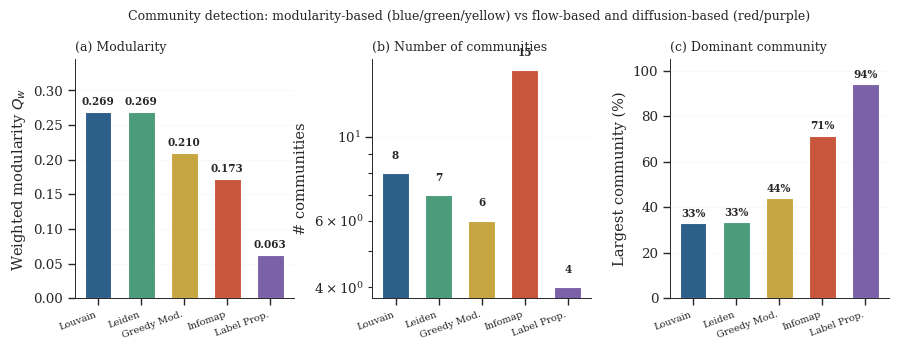

In [ ]:
# ── Fig 1: algos ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.1), gridspec_kw={'wspace': 0.36})

x = np.arange(len(ALGO_ORDER))
colors = [ALGO_PAL[a] for a in ALGO_ORDER]

# (a) w modularity
qvals = [weighted_q(G, partitions[a]) for a in ALGO_ORDER]
bars = axes[0].bar(x, qvals, color=colors, edgecolor='white', width=0.62)
for b, v in zip(bars, qvals):
    axes[0].text(b.get_x() + b.get_width()/2, v + max(qvals)*0.025, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=7.5, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(ALGO_ORDER, fontsize=7, rotation=20, ha='right')
axes[0].set_ylabel('Weighted modularity $Q_w$')
axes[0].set_title('(a) Modularity', fontsize=9, loc='left')
axes[0].set_ylim(0, max(qvals) * 1.28)
axes[0].grid(axis='y', alpha=0.2)

# (b) n communities
kvals = [len(partitions[a]) for a in ALGO_ORDER]
bars = axes[1].bar(x, kvals, color=colors, edgecolor='white', width=0.62)
for b, v in zip(bars, kvals):
    axes[1].text(b.get_x() + b.get_width()/2, v * 1.08, str(v),
                 ha='center', va='bottom', fontsize=7.5, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(ALGO_ORDER, fontsize=7, rotation=20, ha='right')
axes[1].set_ylabel('# communities')
axes[1].set_yscale('log')
axes[1].set_title('(b) Number of communities', fontsize=9, loc='left')
axes[1].grid(axis='y', alpha=0.2)

# (c) largest community size
lvals = [100 * max(len(c) for c in partitions[a]) / G.number_of_nodes()
         for a in ALGO_ORDER]
bars = axes[2].bar(x, lvals, color=colors, edgecolor='white', width=0.62)
for b, v in zip(bars, lvals):
    axes[2].text(b.get_x() + b.get_width()/2, v + 2, f'{v:.0f}%',
                 ha='center', va='bottom', fontsize=7.5, fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(ALGO_ORDER, fontsize=7, rotation=20, ha='right')
axes[2].set_ylabel('Largest community (%)')
axes[2].set_title('(c) Dominant community', fontsize=9, loc='left')
axes[2].set_ylim(0, 105)
axes[2].grid(axis='y', alpha=0.2)

fig.suptitle('Community detection: modularity-based (blue/green/yellow) vs '
             'flow-based and diffusion-based (red/purple)', fontsize=9, y=1.04)
sns.despine()
fig.tight_layout()
savefig(fig, 'cd2_algorithm_comparison')
plt.show()

  saved figures/cd2_nmi_ari_heatmap.png + .pdf


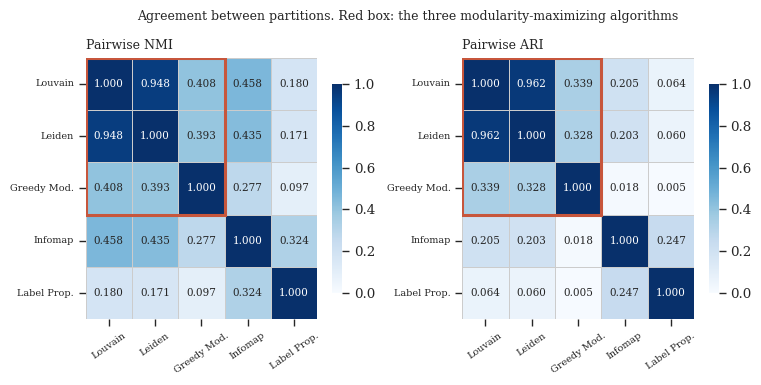

In [ ]:
# ── Fig 2: heatmap NMI and ARI  ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.4), gridspec_kw={'wspace': 0.30})

for ax, mat, title in [(ax1, nmi_mat, 'NMI'), (ax2, ari_mat, 'ARI')]:
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=ALGO_ORDER, yticklabels=ALGO_ORDER,
                linewidths=0.5, linecolor='#cccccc', annot_kws={'size': 7.5},
                cbar_kws={'shrink': 0.8}, ax=ax)
    ax.set_title(f'Pairwise {title}', fontsize=9, loc='left')
    ax.tick_params(axis='x', labelsize=7, rotation=35)
    ax.tick_params(axis='y', labelsize=7, rotation=0)


from matplotlib.patches import Rectangle
for ax in (ax1, ax2):
    ax.add_patch(Rectangle((0, 0), 3, 3, fill=False, edgecolor='#C7563C', lw=2.2))

fig.suptitle('Agreement between partitions. Red box: the three modularity-maximizing '
             'algorithms', fontsize=9, y=1.02)
fig.tight_layout()
savefig(fig, 'cd2_nmi_ari_heatmap')
plt.show()

## 13 - Seasonal community detection 

In [18]:
seasonal = {}

for name in SEASONS:
    path = NETWORKS_DIR / f'{name}_layer.graphml.gz'
    if not os.path.exists(path):
        print(f'  ATTENZIONE: {path} non trovato, salto')
        continue

    L = nx.read_graphml(path)
    try:
        L = nx.relabel_nodes(L, {n: int(n) for n in L.nodes()})
    except ValueError:
        pass

    # Solo i nodi con almeno un arco: gli isolati non sono assegnabili
    L_conn = L.subgraph([n for n, d in L.degree() if d > 0]).copy()
    n_present = L_conn.number_of_nodes()

    print(f'--- {SEASON_NAMES[name]} --- ({n_present:,} nodi connessi, '
          f'{L.number_of_nodes()-n_present:,} isolati)')

    # Sweep di gamma per Louvain
    rows = []
    for gamma in GAMMAS_SEASONAL:
        best, best_q = None, -np.inf
        for _ in range(N_RUNS_SWEEP):
            coms = algorithms.louvain(L_conn, weight=WEIGHT_ATTR,
                                      resolution=gamma, randomize=True)
            q = weighted_q(L_conn, coms.communities)
            if q > best_q:
                best_q, best = q, coms.communities
        sizes = sorted((len(c) for c in best), reverse=True)
        rows.append({'gamma': gamma, 'k': len(sizes), 'Q_w': best_q,
                     'median_size': int(np.median(sizes)),
                     'small_pct': 100*sum(1 for s in sizes if s < MIN_SIZE_FILTER)/len(sizes),
                     'largest_pct': 100*sizes[0]/n_present,
                     'part': best})

    valid = [r for r in rows if r['median_size'] > 1]
    if valid:
        chosen = max(valid, key=lambda r: r['Q_w'])
        criterion = 'declared'
    else:
        chosen = min(rows, key=lambda r: r['small_pct'])
        criterion = 'FALLBACK (nessun gamma con median_size > 1)'

    lou_part = chosen['part']

    # Infomap: nessun parametro da scegliere
    im_p, im_cl = run_infomap(L_conn)

    seasonal[name] = {
        'n_present':   n_present,
        'n_isolates':  L.number_of_nodes() - n_present,
        'sweep':       [{k: v for k, v in r.items() if k != 'part'} for r in rows],
        'gamma_opt':   chosen['gamma'],
        'criterion':   criterion,
        'louvain':     lou_part,
        'louvain_Q':   weighted_q(L_conn, lou_part),
        'louvain_k':   len(lou_part),
        'louvain_k5':  sum(1 for c in lou_part if len(c) >= MIN_SIZE_FILTER),
        'louvain_largest': 100 * max(len(c) for c in lou_part) / n_present,
        'infomap':     im_p,
        'infomap_Q':   weighted_q(L_conn, im_p),
        'infomap_k':   len(im_p),
        'infomap_k5':  sum(1 for c in im_p if len(c) >= MIN_SIZE_FILTER),
        'infomap_largest': 100 * max(len(c) for c in im_p) / n_present,
        'infomap_codelength': im_cl,
        'graph':       L_conn,
    }

    print(f'  Louvain: gamma*={chosen["gamma"]} [{criterion}]  k={len(lou_part)} '
          f'(>=5: {seasonal[name]["louvain_k5"]})  Q_w={seasonal[name]["louvain_Q"]:.4f}')
    print(f'  Infomap: k={len(im_p)} (>=5: {seasonal[name]["infomap_k5"]})  '
          f'Q_w={seasonal[name]["infomap_Q"]:.4f}  codelength={im_cl:.4f}')
    print()

--- Winter_0 --- (944 nodi connessi, 2,065 isolati)
  Louvain: gamma*=2.0 [FALLBACK (nessun gamma con median_size > 1)]  k=146 (>=5: 32)  Q_w=0.1007
  Infomap: k=25 (>=5: 9)  Q_w=0.0177  codelength=8.5619

--- Spring --- (2,202 nodi connessi, 807 isolati)
  Louvain: gamma*=2.0 [FALLBACK (nessun gamma con median_size > 1)]  k=195 (>=5: 41)  Q_w=0.1531
  Infomap: k=17 (>=5: 8)  Q_w=0.0226  codelength=9.5862

--- Summer --- (2,698 nodi connessi, 311 isolati)
  Louvain: gamma*=2.0 [FALLBACK (nessun gamma con median_size > 1)]  k=139 (>=5: 27)  Q_w=0.2844
  Infomap: k=10 (>=5: 7)  Q_w=0.3445  codelength=9.7875

--- Autumn --- (2,157 nodi connessi, 852 isolati)
  Louvain: gamma*=1.25 [FALLBACK (nessun gamma con median_size > 1)]  k=88 (>=5: 12)  Q_w=0.1720
  Infomap: k=21 (>=5: 9)  Q_w=0.0803  codelength=9.8600

--- Winter_1 --- (959 nodi connessi, 2,050 isolati)
  Louvain: gamma*=1.5 [FALLBACK (nessun gamma con median_size > 1)]  k=125 (>=5: 22)  Q_w=0.0983
  Infomap: k=14 (>=5: 5)  Q_w=0.0

In [ ]:
rows = []
for name in SEASONS:
    if name not in seasonal:
        continue
    s = seasonal[name]
    rows.append({
        'Season':      SEASON_NAMES[name],
        'Present':     s['n_present'],
        'gamma*':      s['gamma_opt'],
        'Criterion':   'fallback' if s['criterion'].startswith('FALLBACK') else 'declared',
        'Lou k':       s['louvain_k'],
        'Lou k>=5':    s['louvain_k5'],
        'Lou Q_w':     round(s['louvain_Q'], 4),
        'IM k':        s['infomap_k'],
        'IM k>=5':     s['infomap_k5'],
        'IM Q_w':      round(s['infomap_Q'], 4),
        'IM codelen':  round(s['infomap_codelength'], 3),
    })
df_seasonal = pd.DataFrame(rows).set_index('Season')
print('SEASONAL COMMUNITY DETECTION — Louvain vs Infomap')
print(df_seasonal.to_string())
print()

n_fallback = sum(1 for n in SEASONS if n in seasonal
                 and seasonal[n]['criterion'].startswith('FALLBACK'))


In [ ]:
# NMI cross-season
def n2c(partition, graph):
    d = {n: -1 for n in graph.nodes()}
    for i, com in enumerate(partition):
        for n in com:
            d[n] = i
    return d

all_nodes = list(G.nodes())
cross = {}
for algo in ['louvain', 'infomap']:
    maps = {name: n2c(seasonal[name][algo], seasonal[name]['graph'])
            for name in SEASONS if name in seasonal}
    seas = [s for s in SEASONS if s in maps]
    mat = np.full((len(seas), len(seas)), np.nan)
    for i, s1 in enumerate(seas):
        for j, s2 in enumerate(seas):
            if i == j:
                mat[i, j] = 1.0
                continue
            shared = [n for n in all_nodes
                      if maps[s1].get(n, -1) >= 0 and maps[s2].get(n, -1) >= 0]
            if len(shared) < 10:
                continue
            la = np.array([maps[s1][n] for n in shared])
            lb = np.array([maps[s2][n] for n in shared])
            mat[i, j] = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    cross[algo] = pd.DataFrame(mat, index=[SEASON_NAMES[s] for s in seas],
                               columns=[SEASON_NAMES[s] for s in seas])
    print(f'Cross-season NMI — {algo}:')
    print(cross[algo].round(3).to_string())
    print()

for algo in ['louvain', 'infomap']:
    m = cross[algo].values.copy()
    np.fill_diagonal(m, np.nan)
    i, j = np.unravel_index(np.nanargmax(m), m.shape)
    print(f'{algo}: massimo fuori diagonale = {m[i,j]:.3f} '
          f'({cross[algo].index[i]} vs {cross[algo].columns[j]})')
    w0w1 = cross[algo].loc[SEASON_NAMES["winter_0"], SEASON_NAMES["winter_1"]]
    print(f'{algo}: Winter_0 vs Winter_1 = {w0w1:.3f}')

Cross-season NMI — louvain:
          Winter_0  Spring  Summer  Autumn  Winter_1
Winter_0     1.000   0.504   0.405   0.361     0.518
Spring       0.504   1.000   0.404   0.373     0.472
Summer       0.405   0.404   1.000   0.378     0.394
Autumn       0.361   0.373   0.378   1.000     0.350
Winter_1     0.518   0.472   0.394   0.350     1.000

Cross-season NMI — infomap:
          Winter_0  Spring  Summer  Autumn  Winter_1
Winter_0     1.000   0.269   0.224   0.244     0.189
Spring       0.269   1.000   0.275   0.407     0.336
Summer       0.224   0.275   1.000   0.344     0.303
Autumn       0.244   0.407   0.344   1.000     0.379
Winter_1     0.189   0.336   0.303   0.379     1.000

louvain: massimo fuori diagonale = 0.518 (Winter_0 vs Winter_1)
louvain: Winter_0 vs Winter_1 = 0.518
infomap: massimo fuori diagonale = 0.407 (Autumn vs Spring)
infomap: Winter_0 vs Winter_1 = 0.189


## 14 - Export 

In [ ]:
n2c_annual = {lab: n2c(partitions[lab], G) for lab in ALGO_ORDER}
COL = {'Louvain': 'louvain', 'Leiden': 'leiden', 'Greedy Mod.': 'greedy',
       'Infomap': 'infomap', 'Label Prop.': 'lpa'}

records = []
for n, d in G.nodes(data=True):
    row = {'taxon_id': n,
           'species_name': d.get('species_name', ''),
           'iconic_taxon': iconic_map.get(n, 'Other')}
    for lab in ALGO_ORDER:
        row[f'{COL[lab]}_community'] = n2c_annual[lab][n]
    records.append(row)

df_annual = pd.DataFrame(records)
df_annual.to_csv(OUT_ANNUAL, index=False)
print(f'Esportato {len(df_annual):,} nodi -> {OUT_ANNUAL}')
print(f'Colonne: {list(df_annual.columns)}')
print()

records = []
for n, d in G.nodes(data=True):
    row = {'taxon_id': n,
           'species_name': d.get('species_name', ''),
           'iconic_taxon': iconic_map.get(n, 'Other'),
           'annual_louvain': n2c_annual['Louvain'][n],
           'annual_infomap': n2c_annual['Infomap'][n]}
    for name in SEASONS:
        if name not in seasonal:
            row[f'{name}_louvain'] = -1
            row[f'{name}_infomap'] = -1
            continue
        row[f'{name}_louvain'] = n2c(seasonal[name]['louvain'],
                                     seasonal[name]['graph']).get(n, -1)
        row[f'{name}_infomap'] = n2c(seasonal[name]['infomap'],
                                     seasonal[name]['graph']).get(n, -1)
    records.append(row)

df_seas = pd.DataFrame(records)
df_seas.to_csv(OUT_SEASONAL, index=False)
print(f'Esportato {len(df_seas):,} nodi -> {OUT_SEASONAL}')
print(f'Colonne: {list(df_seas.columns)}')

Esportato 3,009 nodi -> data/networks/community_assignments_annual_v2.csv
Colonne: ['taxon_id', 'species_name', 'iconic_taxon', 'louvain_community', 'leiden_community', 'greedy_community', 'infomap_community', 'lpa_community']

Esportato 3,009 nodi -> data/networks/community_assignments_seasonal_v2.csv
Colonne: ['taxon_id', 'species_name', 'iconic_taxon', 'annual_louvain', 'annual_infomap', 'winter_0_louvain', 'winter_0_infomap', 'spring_louvain', 'spring_infomap', 'summer_louvain', 'summer_infomap', 'autumn_louvain', 'autumn_infomap', 'winter_1_louvain', 'winter_1_infomap']


In [ ]:
# ───────────────────────────────────
results = {
    'graph':      {'nodes': G.number_of_nodes(), 'edges': G.number_of_edges()},
    'gamma_opt':  GAMMA_OPT,
    'sweep':      sweep_rows,
    'algorithms': df_algos.reset_index().to_dict('records'),
    'infomap_codelength': float(im_codelength),
    'lpa_variability':    extras.get('Label Prop.', {}),
    'nmi':        df_nmi.round(4).to_dict(),
    'ari':        df_ari.round(4).to_dict(),
    'purity':     purity_summary,
    'baseline':   BASELINE_FREQ,
    'stratified': df_strat.reset_index().to_dict('records'),
    'null_models': {
        'real': {'Q_uw': float(best_q_uw), 'infomap_k': len(real_im_part),
                 'codelength': float(real_im_cl)},
        'ER': {k: [float(x) for x in v] for k, v in null_stats['ER'].items()},
        'BA': {k: [float(x) for x in v] for k, v in null_stats['BA'].items()},
    },
    'seasonal': {name: {k: v for k, v in s.items()
                        if k not in ('louvain', 'infomap', 'graph')}
                 for name, s in seasonal.items()},
    'cross_season_nmi': {a: cross[a].round(4).to_dict() for a in cross},
}

with open(OUT_JSON, 'w') as f:
    json.dump(results, f, indent=2, default=float)
print(f'Salvato {OUT_JSON}')

Salvato data/analysis/community_results_v2.json
